# Module 06: OpenCV for Computer Vision & Machine Learning
## Notebook 01: Image Basics, File I/O, and Color Spaces

OpenCV (Open Source Computer Vision Library) is the premier open-source library for computer vision, image processing, and real-time visual analysis. In modern machine learning and deep learning pipelines, OpenCV powers data ingestion, visual feature engineering, spatial normalization, and real-time inference preprocessing.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Understand how digital images are represented as multidimensional **NumPy ndarrays** ($H \times W \times C$) and understand coordinate systems.
2. Load and persist images using `cv2.imread()` and `cv2.imwrite()` with flags and compression parameters.
3. Master the crucial **BGR vs. RGB** channel ordering distinction between OpenCV and Matplotlib.
4. Extract Regions of Interest (ROI), split, merge, and manipulate individual color channels.
5. Navigate and convert between color spaces: **RGB**, **HSV** (Hue-Saturation-Value), and **LAB** ($L^*a^*b^*$).
6. **Advanced:** Build an **HSV Color Segmentation Pipeline** using range masking and bitwise operators.
7. **Advanced:** Implement **Contrast Limited Adaptive Histogram Equalization (CLAHE)** on luminance channels for robust contrast enhancement without chromatic distortion.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Dynamic path resolution: works from either repo root or module directory
img_dir = "images" if os.path.exists("images") else "../images"
print(f"OpenCV Version: {cv2.__version__}")
print(f"Image Directory: {os.path.abspath(img_dir)}")

OpenCV Version: 5.0.0
Image Directory: /home/admin/notebooks/images


### 1. Digital Image Representation in Memory
In OpenCV, every image is stored as a standard **NumPy ndarray**:
- **Grayscale images:** 2D array of shape `(Height, Width)` with dtype `uint8` (values in $[0, 255]$).
- **Color images:** 3D array of shape `(Height, Width, Channels)` with dtype `uint8`.
- Coordinate system convention: origin $(0, 0)$ is at the **top-left corner**.
  - $x$ increases to the right ($0 \le x < \text{Width}$).
  - $y$ increases downwards ($0 \le y < \text{Height}$).
  - In NumPy indexing: `img[y, x, c]` (row-major: Height then Width).

Canvas shape: (300, 300, 3), dtype: uint8, min: 0, max: 255


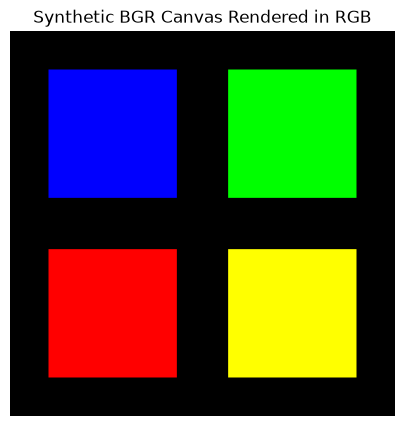

In [2]:
# Creating a synthetic 3-channel test pattern from scratch
canvas = np.zeros((300, 300, 3), dtype=np.uint8)

# Paint color blocks (BGR convention in OpenCV)
canvas[30:130, 30:130] = [255, 0, 0]      # Blue block (BGR: 255, 0, 0)
canvas[30:130, 170:270] = [0, 255, 0]     # Green block (BGR: 0, 255, 0)
canvas[170:270, 30:130] = [0, 0, 255]     # Red block (BGR: 0, 0, 255)
canvas[170:270, 170:270] = [0, 255, 255]  # Yellow block (BGR: 0, 255, 255)

print(f"Canvas shape: {canvas.shape}, dtype: {canvas.dtype}, min: {canvas.min()}, max: {canvas.max()}")

# Convert to RGB for proper display with Matplotlib
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Synthetic BGR Canvas Rendered in RGB")
plt.axis("off")
plt.show()

### 2. Image Loading, I/O Flags, and the BGR vs. RGB Pitfall
OpenCV was originally developed when BGR was the standard hardware camera format. Consequently, `cv2.imread()` loads images in **BGR** order by default.
- Matplotlib and modern deep learning frameworks (PyTorch, TensorFlow) expect **RGB** order.
- Forgetting to convert with `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` results in swapped red and blue channels (faces look blue, skies look orange).

Common `cv2.imread()` flags:
- `cv2.IMREAD_COLOR` (default, 1): Loads a 3-channel BGR image.
- `cv2.IMREAD_GRAYSCALE` (0): Loads as a single-channel 8-bit grayscale image.
- `cv2.IMREAD_UNCHANGED` (-1): Loads including alpha transparency channel (BGRA).

Color image shape: (480, 640, 3), dtype: uint8
Grayscale image shape: (480, 640), dtype: uint8


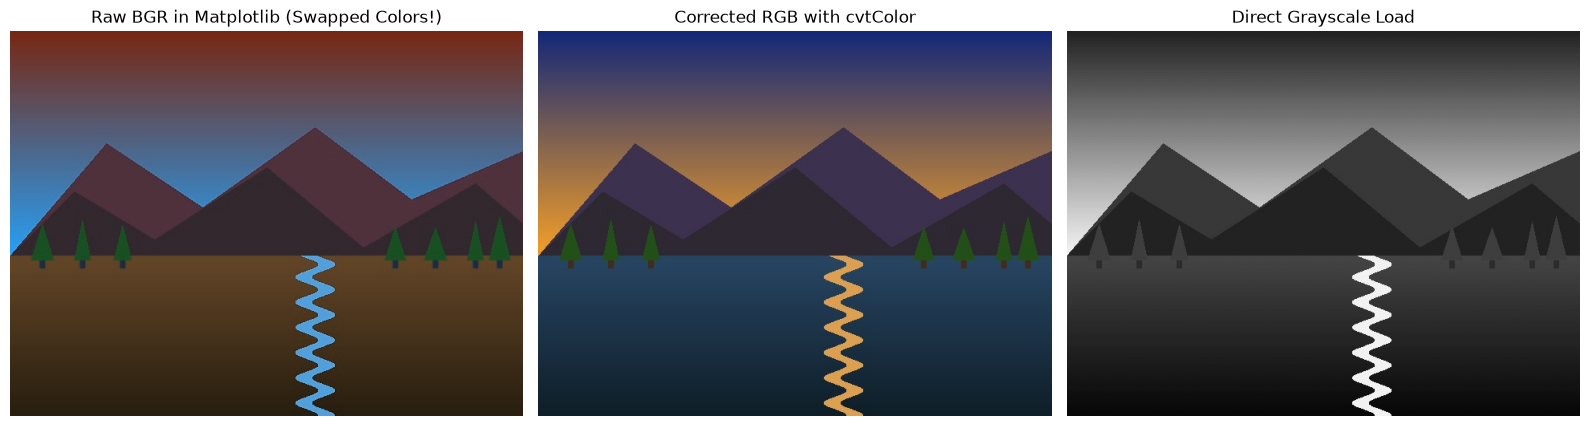

In [3]:
landscape_path = os.path.join(img_dir, "landscape.jpg")

# 1. Read in default BGR color mode
img_bgr = cv2.imread(landscape_path, cv2.IMREAD_COLOR)
assert img_bgr is not None, f"Failed to load image from {landscape_path}"

# 2. Read in Grayscale mode
img_gray = cv2.imread(landscape_path, cv2.IMREAD_GRAYSCALE)

# 3. Convert BGR to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Color image shape: {img_bgr.shape}, dtype: {img_bgr.dtype}")
print(f"Grayscale image shape: {img_gray.shape}, dtype: {img_gray.dtype}")

# Visualizing the BGR vs RGB pitfall
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_bgr)
axes[0].set_title("Raw BGR in Matplotlib (Swapped Colors!)")
axes[0].axis("off")

axes[1].imshow(img_rgb)
axes[1].set_title("Corrected RGB with cvtColor")
axes[1].axis("off")

axes[2].imshow(img_gray, cmap="gray")
axes[2].set_title("Direct Grayscale Load")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 3. Slicing Regions of Interest (ROI) & Channel Decomposition
Because images are NumPy arrays, spatial cropping (Region of Interest) and channel manipulation require zero memory overhead using standard strided slicing:
- **ROI Slicing:** `crop = img[y_min:y_max, x_min:x_max]`
- **Channel Extraction:** `b, g, r = cv2.split(img_bgr)` or `img_bgr[:, :, 0]`
- **Channel Merging:** `cv2.merge([b, g, r])`

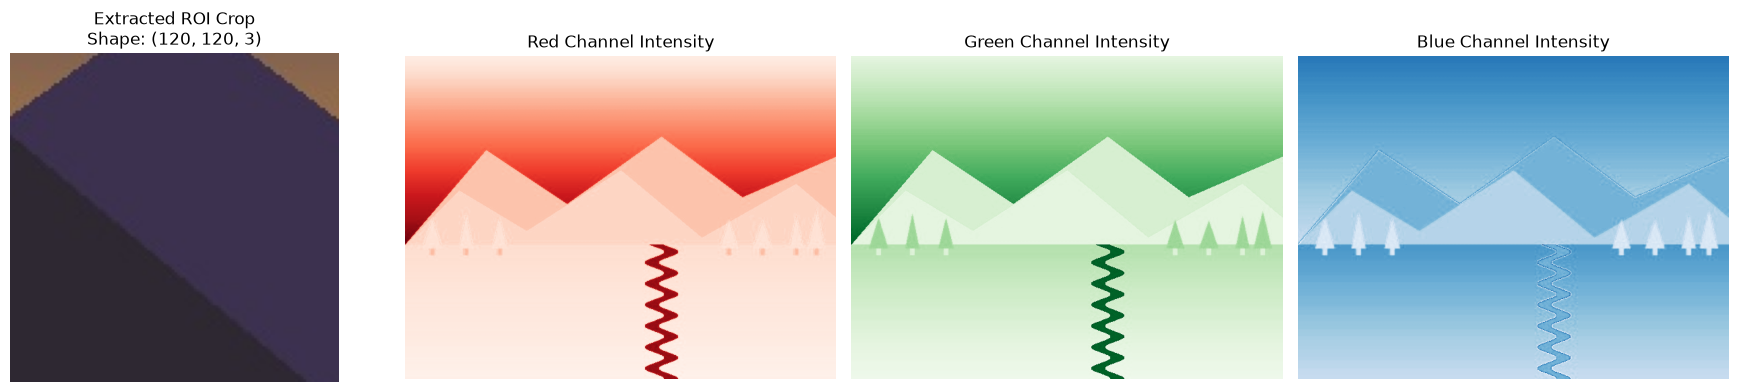

In [4]:
# Extract Region of Interest (the glowing sun disc and mountain peak)
# In landscape.jpg: sun is centered around y ~ 200, x ~ 380
roi = img_rgb[140:260, 320:440]

# Split color channels
r, g, b = cv2.split(img_rgb)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(roi)
axes[0].set_title(f"Extracted ROI Crop\nShape: {roi.shape}")
axes[0].axis("off")

axes[1].imshow(r, cmap="Reds")
axes[1].set_title("Red Channel Intensity")
axes[1].axis("off")

axes[2].imshow(g, cmap="Greens")
axes[2].set_title("Green Channel Intensity")
axes[2].axis("off")

axes[3].imshow(b, cmap="Blues")
axes[3].set_title("Blue Channel Intensity")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 4. Advanced Color Spaces: HSV and Perceptually Uniform LAB
While RGB is ubiquitous in displays, it couples color and illumination tightly, making color detection brittle under varying lighting:
1. **HSV (Hue, Saturation, Value):**
   - **Hue ($H$):** The base color angle ($0^\circ$ to $360^\circ$). In OpenCV, stored as $0 \le H \le 179$ (to fit within `uint8`).
   - **Saturation ($S$):** Purity / vibrancy of color ($0 \le S \le 255$).
   - **Value ($V$):** Brightness / luminance intensity ($0 \le V \le 255$).
   - *Key Advantage:* Isolates illumination changes to the $V$ channel!

2. **LAB ($L^*, a^*, b^*$):**
   - **$L^*$:** Lightness ($0 \le L \le 255$ in OpenCV).
   - **$a^*$:** Green-to-Red opponent color axis.
   - **$b^*$:** Blue-to-Yellow opponent color axis.
   - *Key Advantage:* Perceptually uniform (Euclidean distance between colors matches human perceived difference).

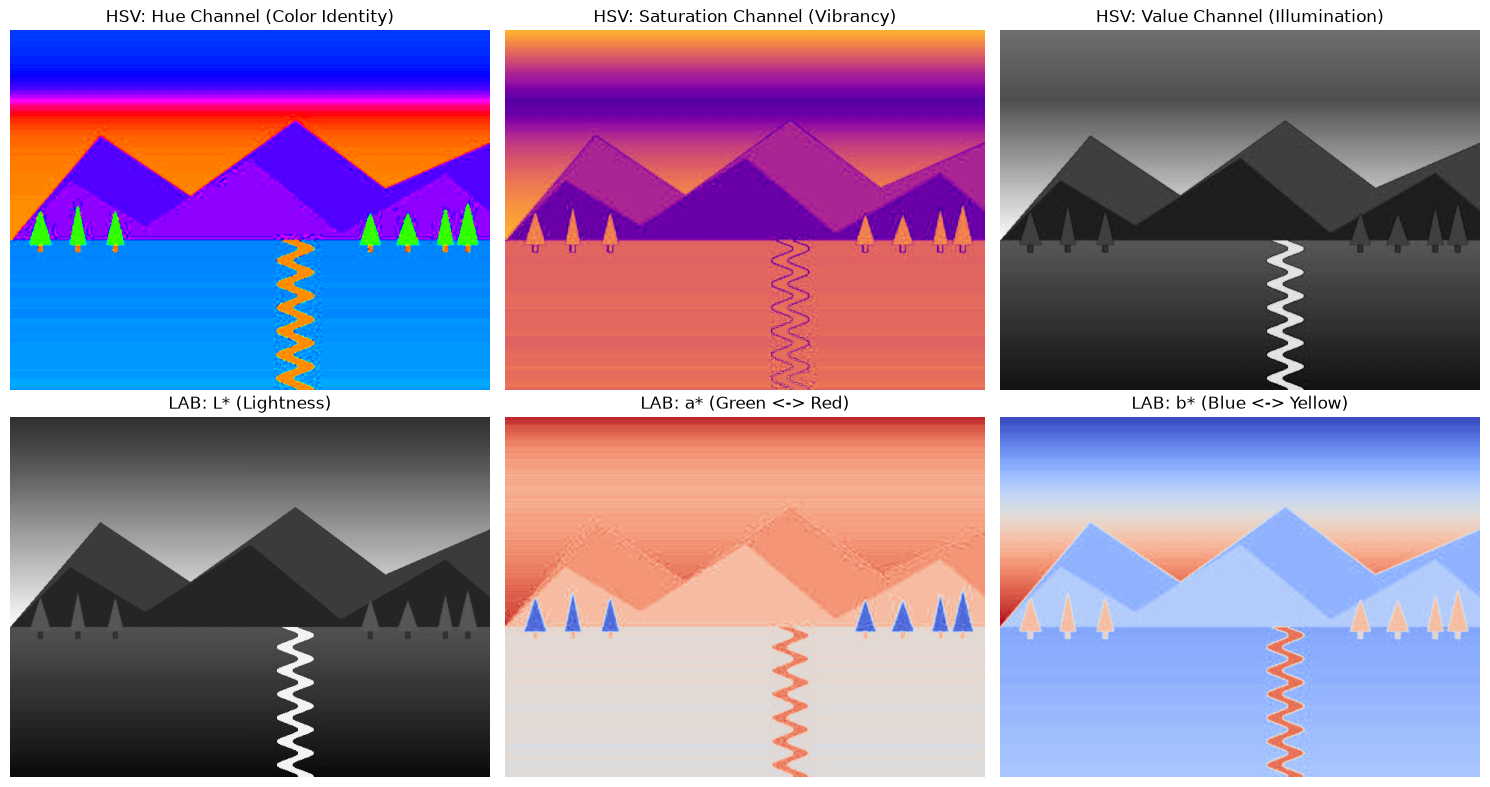

In [5]:
# Convert to HSV and LAB color spaces
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

h_ch, s_ch, v_ch = cv2.split(img_hsv)
l_ch, a_ch, b_ch = cv2.split(img_lab)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(h_ch, cmap="hsv")
axes[0, 0].set_title("HSV: Hue Channel (Color Identity)")
axes[0, 0].axis("off")

axes[0, 1].imshow(s_ch, cmap="plasma")
axes[0, 1].set_title("HSV: Saturation Channel (Vibrancy)")
axes[0, 1].axis("off")

axes[0, 2].imshow(v_ch, cmap="gray")
axes[0, 2].set_title("HSV: Value Channel (Illumination)")
axes[0, 2].axis("off")

axes[1, 0].imshow(l_ch, cmap="gray")
axes[1, 0].set_title("LAB: L* (Lightness)")
axes[1, 0].axis("off")

axes[1, 1].imshow(a_ch, cmap="coolwarm")
axes[1, 1].set_title("LAB: a* (Green <-> Red)")
axes[1, 1].axis("off")

axes[1, 2].imshow(b_ch, cmap="coolwarm")
axes[1, 2].set_title("LAB: b* (Blue <-> Yellow)")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

### 5. Complex Application 1: HSV Color Segmentation Pipeline
In real-world computer vision (e.g. self-driving lane tracking, robotic arm sorting, object tracking), we segment objects by their invariant Hue and Saturation properties:
1. Define lower and upper HSV bounds: $[\text{Hue}_{\min}, \text{Sat}_{\min}, \text{Val}_{\min}]$ and $[\text{Hue}_{\max}, \text{Sat}_{\max}, \text{Val}_{\max}]$.
2. Generate a binary mask using `cv2.inRange()`.
3. Apply the mask to the original image using bitwise AND: `cv2.bitwise_and(img, img, mask=mask)`.

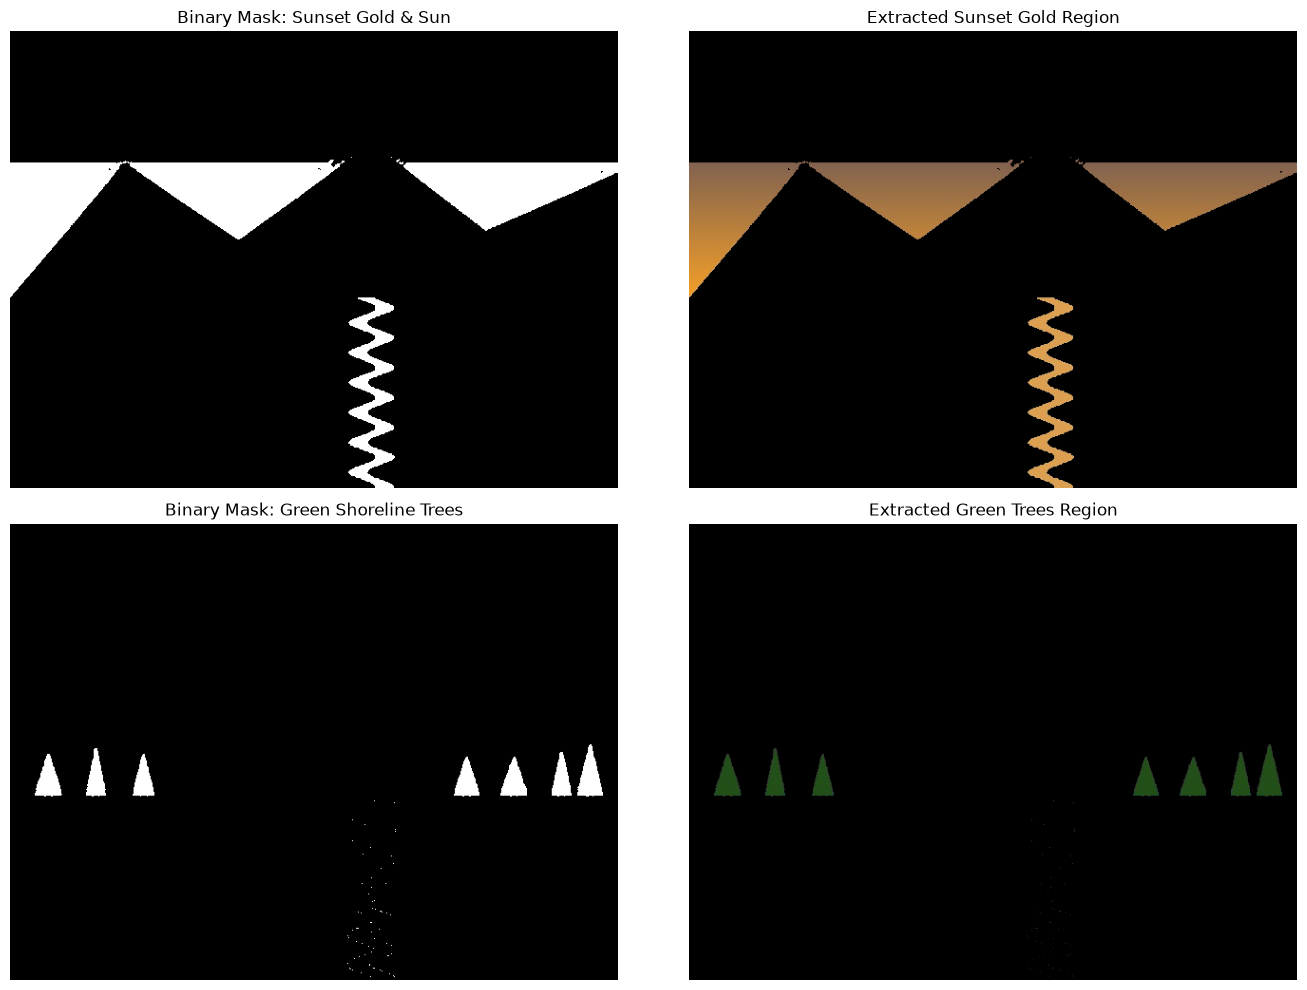

In [6]:
# Target: Segment the golden/orange sunset sky and sun
# Hue for yellow/orange is roughly in range [10, 35] in OpenCV's [0, 179] scale
lower_sunset = np.array([10, 100, 120], dtype=np.uint8)
upper_sunset = np.array([35, 255, 255], dtype=np.uint8)

# Target: Segment the shoreline green pine trees
# Hue for green is roughly in range [35, 85]
lower_green = np.array([35, 40, 30], dtype=np.uint8)
upper_green = np.array([85, 255, 180], dtype=np.uint8)

# Create binary masks
mask_sunset = cv2.inRange(img_hsv, lower_sunset, upper_sunset)
mask_green = cv2.inRange(img_hsv, lower_green, upper_green)

# Apply bitwise masking to isolate target colors
res_sunset = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_sunset)
res_green = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_green)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(mask_sunset, cmap="gray")
axes[0, 0].set_title("Binary Mask: Sunset Gold & Sun")
axes[0, 0].axis("off")

axes[0, 1].imshow(res_sunset)
axes[0, 1].set_title("Extracted Sunset Gold Region")
axes[0, 1].axis("off")

axes[1, 0].imshow(mask_green, cmap="gray")
axes[1, 0].set_title("Binary Mask: Green Shoreline Trees")
axes[1, 0].axis("off")

axes[1, 1].imshow(res_green)
axes[1, 1].set_title("Extracted Green Trees Region")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### 6. Complex Application 2: Histogram Equalization vs. CLAHE
Histogram Equalization enhances image contrast by spreading out the most frequent intensity values:
- **Global Histogram Equalization (`cv2.equalizeHist`):** Considers the global image histogram. Frequently amplifies background noise in dark or bright regions.
- **CLAHE (Contrast Limited Adaptive Histogram Equalization):**
  - Divides the image into contextual tiles (e.g. $8 \times 8$).
  - Equalizes each tile independently.
  - Applies a **clip limit** (e.g. 2.0 or 3.0) to prevent over-amplification of noise.
  - Bilinearly interpolates neighboring tile boundaries to eliminate artificial seams.
- **Best Practice for Color Images:** Convert to **LAB**, apply CLAHE *only* to the Lightness channel ($L^*$), and merge back to BGR/RGB. This enhances contrast without distorting colors!

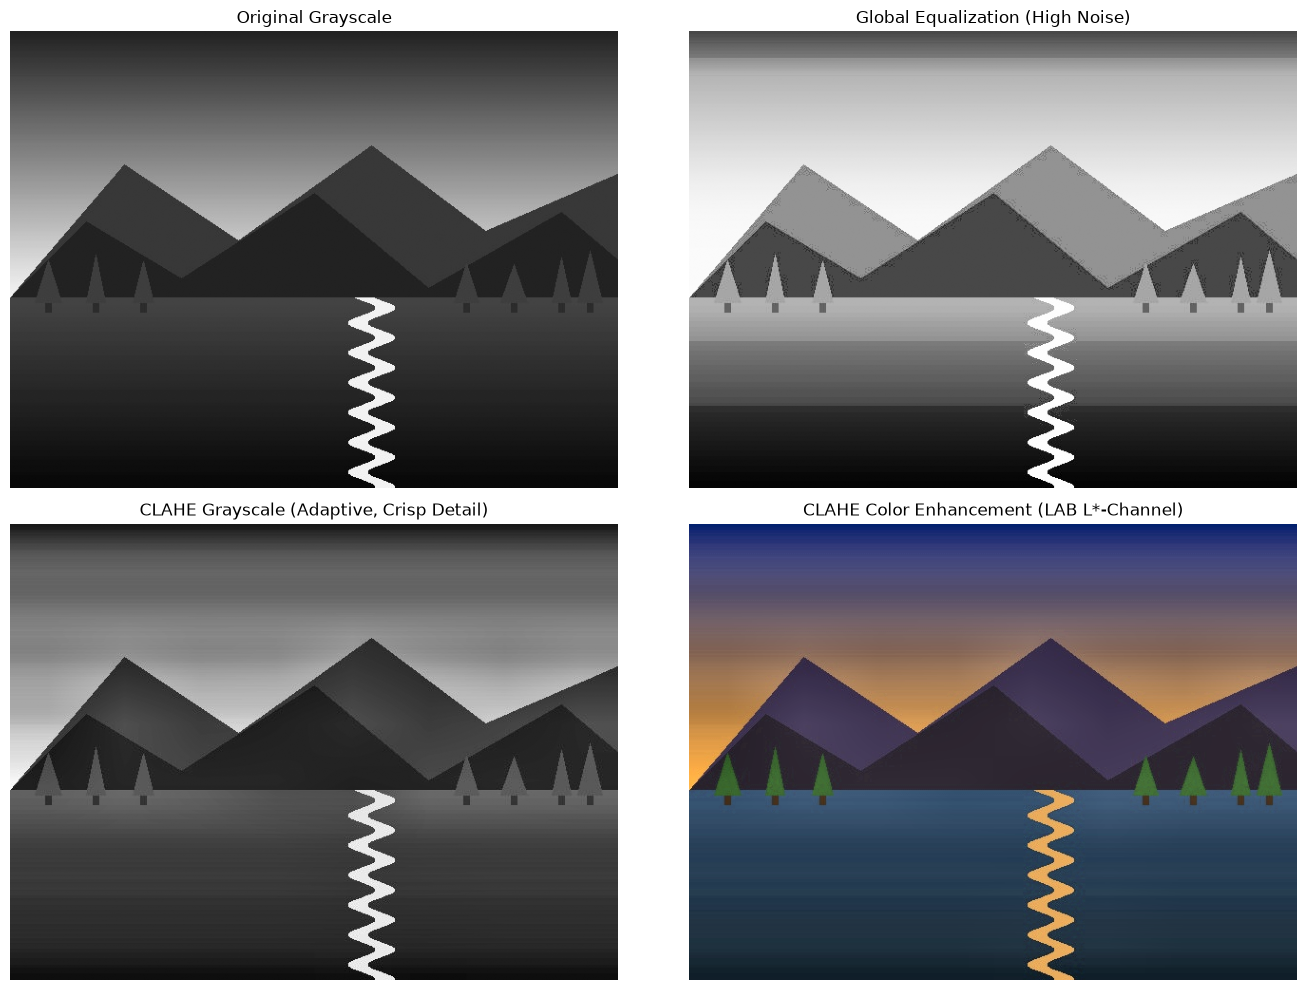

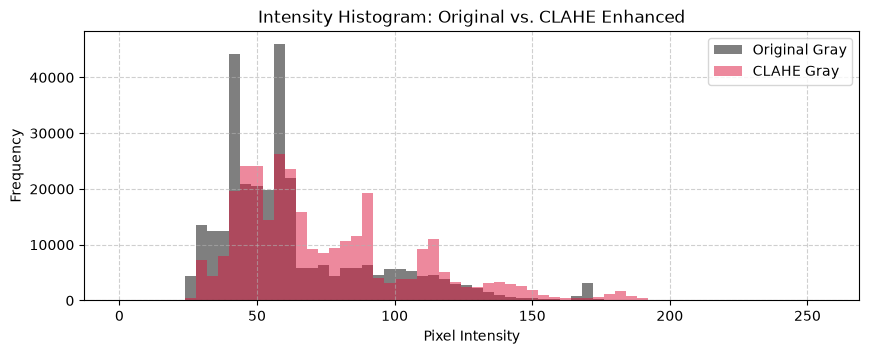

In [7]:
# 1. Global Histogram Equalization on Grayscale
equalized_gray = cv2.equalizeHist(img_gray)

# 2. CLAHE on Grayscale
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
clahe_gray = clahe.apply(img_gray)

# 3. Production Pipeline: CLAHE on Color Image via LAB Space
lab_plane = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
l_channel, a_channel, b_channel = cv2.split(lab_plane)

# Apply CLAHE to L-channel only
l_clahe = clahe.apply(l_channel)

# Merge back and convert to RGB
lab_enhanced = cv2.merge([l_clahe, a_channel, b_channel])
bgr_enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)
rgb_enhanced = cv2.cvtColor(bgr_enhanced, cv2.COLOR_BGR2RGB)

# Compare results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_gray, cmap="gray")
axes[0, 0].set_title("Original Grayscale")
axes[0, 0].axis("off")

axes[0, 1].imshow(equalized_gray, cmap="gray")
axes[0, 1].set_title("Global Equalization (High Noise)")
axes[0, 1].axis("off")

axes[1, 0].imshow(clahe_gray, cmap="gray")
axes[1, 0].set_title("CLAHE Grayscale (Adaptive, Crisp Detail)")
axes[1, 0].axis("off")

axes[1, 1].imshow(rgb_enhanced)
axes[1, 1].set_title("CLAHE Color Enhancement (LAB L*-Channel)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# Verify channel intensity histogram shifts
plt.figure(figsize=(10, 3.5))
plt.hist(img_gray.ravel(), bins=64, range=(0, 256), alpha=0.5, color="black", label="Original Gray")
plt.hist(clahe_gray.ravel(), bins=64, range=(0, 256), alpha=0.5, color="crimson", label="CLAHE Gray")
plt.title("Intensity Histogram: Original vs. CLAHE Enhanced")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()